In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
import matplotlib.pyplot as plt



In [2]:
vocab_size = 10000   # Use top 10,000 frequent words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Samples : 25000
Testing Samples  : 25000


In [3]:
max_length = 200

X_train = tf.keras.preprocessing.sequence.pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post'
)

X_test = tf.keras.preprocessing.sequence.pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post'
)



In [4]:
model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=32,
              input_length=max_length),

    GlobalAveragePooling1D(),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6496 - loss: 0.6835 - val_accuracy: 0.6830 - val_loss: 0.6640
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7471 - loss: 0.6317 - val_accuracy: 0.7646 - val_loss: 0.5838
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8067 - loss: 0.5292 - val_accuracy: 0.8036 - val_loss: 0.4803
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8414 - loss: 0.4263 - val_accuracy: 0.8408 - val_loss: 0.4026
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8626 - loss: 0.3581 - val_accuracy: 0.8460 - val_loss: 0.3630
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8806 - loss: 0.3141 - val_accuracy: 0.8582 - val_loss: 0.3395
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8913 - loss: 0.2849 - val_accuracy: 0.8712 - val_loss: 0.3204
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8985 - loss: 0.2638 - val_accuracy: 0.8540 - v

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8727 - loss: 0.3004

Test Loss : 0.30039477348327637
Test Accuracy : 0.8727200031280518


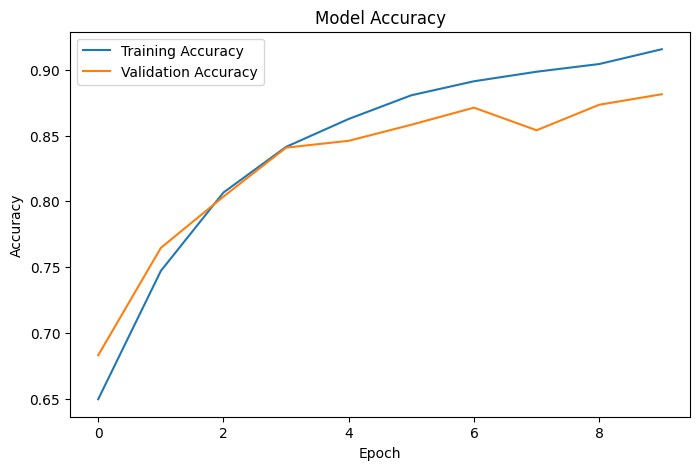

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


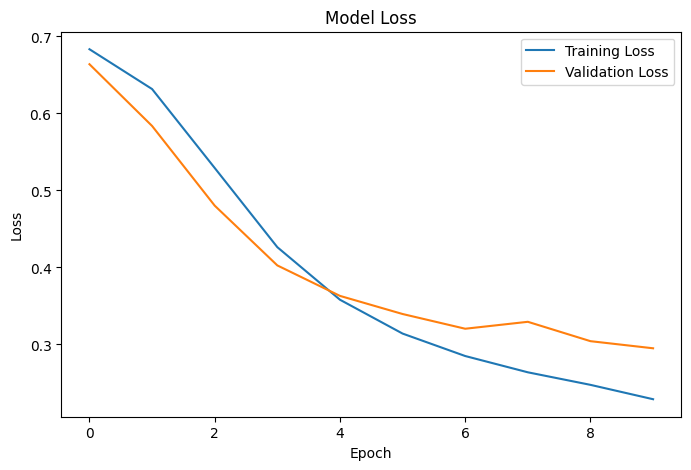

In [10]:

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()
